# Validación de un modelo de forecasting de ventas (QSR)

**Objetivo:** demostrar que un modelo de proyección de ventas diarias para una
cadena de restaurantes de comida rápida es confiable *antes* de usarlo, mediante
un **backtest**: se entrena con años pasados y se le pide "predecir" un año que
ya conocemos, para medir su error real.

> **Datos:** 100% sintéticos, generados por simulación (`data/generate_synthetic_data.py`).
> No provienen de ninguna empresa real. El objetivo del repositorio es mostrar la
> **metodología**, no resultados de negocio de un tercero.

**Métrica principal:** MAPE (error porcentual absoluto medio). En un proyecto real
de planificación, un MAPE mensual de un dígito bajo se considera muy bueno.


In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.options.display.float_format = lambda x: f"{x:,.2f}" 

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importing plotly failed. Interactive plots will not work.


## 1. Cargar datos y agregar a nivel cadena

Partimos de ventas diarias por tienda y las sumamos a una sola serie diaria de
toda la cadena (que es la serie que se proyecta a nivel agregado).

In [2]:
df = pd.read_csv("../data/ventas_sinteticas.csv", parse_dates=["fechacierre"])

daily = (
    df.groupby("fechacierre", as_index=False)["ventaneta"].sum()
      .rename(columns={"fechacierre": "ds", "ventaneta": "y"})
      .sort_values("ds")
)

print(f"Rango: {daily['ds'].min().date()} a {daily['ds'].max().date()}")
print(f"Días: {len(daily):,}")
daily.head()

Rango: 2021-01-01 a 2025-12-31
Días: 1,826


,ds,y
0,2021-01-01,"34,327,427.49"
1,2021-01-02,"32,400,859.61"
2,2021-01-03,"25,597,973.56"
3,2021-01-04,"19,966,202.12"
4,2021-01-05,"19,389,325.02"


## 2. Separar entrenamiento y prueba

Entrenamos con **2021–2024** y dejamos **2025** como año de prueba. El modelo
nunca ve 2025 durante el entrenamiento: así medimos su capacidad real de
generalizar, no de memorizar.

In [3]:
train = daily[daily["ds"] < "2025-01-01"].copy()
test  = daily[(daily["ds"] >= "2025-01-01") & (daily["ds"] <= "2025-12-31")].copy()

print(f"Entrenamiento: {len(train):,} días (2021-2024)")
print(f"Prueba:        {len(test):,} días (2025)")

Entrenamiento: 1,461 días (2021-2024)
Prueba:        365 días (2025)


## 3. Entrenar el modelo (Prophet)

Usamos Prophet con estacionalidad **anual** y **semanal** activadas. Estos dos
componentes capturan los dos patrones dominantes en un QSR: la temporada del año
y el fuerte efecto de fin de semana.

In [4]:
model = Prophet(
    growth="linear",
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
)
model.fit(train)
print("Modelo entrenado.")

16:02:49 - cmdstanpy - INFO - Chain [1] start processing


16:02:49 - cmdstanpy - INFO - Chain [1] done processing


Modelo entrenado.


## 4. Proyectar 2025 y comparar contra lo real

In [5]:
future = model.make_future_dataframe(periods=365, freq="D")
forecast = model.predict(future)

fc_2025 = forecast[
    (forecast["ds"] >= "2025-01-01") & (forecast["ds"] <= "2025-12-31")
][["ds", "yhat"]]

comparison = test[["ds", "y"]].merge(fc_2025, on="ds", how="inner")
comparison.head()

,ds,y,yhat
0,2025-01-01,"32,764,243.05","32,638,510.14"
1,2025-01-02,"30,313,718.04","33,908,507.77"
2,2025-01-03,"38,453,769.60","41,852,472.64"
3,2025-01-04,"40,406,920.58","43,549,784.59"
4,2025-01-05,"32,319,138.36","35,920,456.72"


## 5. Métricas de validación

Agregamos a nivel **mensual** (la granularidad típica de un PPTO) y calculamos:

- **MAPE mensual:** error porcentual promedio mes a mes.
- **Bias anual:** si el modelo sobre- o subestima en el agregado del año.
- **MAPE diario:** error a nivel día (naturalmente más alto que el mensual).

In [6]:
comparison["month"] = comparison["ds"].dt.to_period("M")
monthly = comparison.groupby("month")[["y", "yhat"]].sum().reset_index()

mape_monthly = mean_absolute_percentage_error(monthly["y"], monthly["yhat"])
mape_daily   = mean_absolute_percentage_error(comparison["y"], comparison["yhat"])
bias_annual  = (monthly["yhat"].sum() - monthly["y"].sum()) / monthly["y"].sum()

print("==============================================")
print("   RESULTADOS DE VALIDACIÓN — AÑO 2025")
print("==============================================")
print(f"MAPE mensual : {mape_monthly:.2%}")
print(f"MAPE diario  : {mape_daily:.2%}")
print(f"Bias anual   : {bias_annual:+.2%}")
print("----------------------------------------------")
print(f"Real 2025     : {monthly['y'].sum():,.0f}")
print(f"Forecast 2025 : {monthly['yhat'].sum():,.0f}")
print("==============================================")

   RESULTADOS DE VALIDACIÓN — AÑO 2025
MAPE mensual : 0.88%
MAPE diario  : 3.34%
Bias anual   : +0.14%
----------------------------------------------
Real 2025     : 12,895,456,577
Forecast 2025 : 12,914,152,548


## 6. Visual: real vs. forecast (mensual)

Los valores del eje se muestran en **índice (base 100 = enero real)** en lugar de
montos absolutos, porque en un proyecto real las cifras serían confidenciales. La
forma de la curva es lo que demuestra el ajuste del modelo.

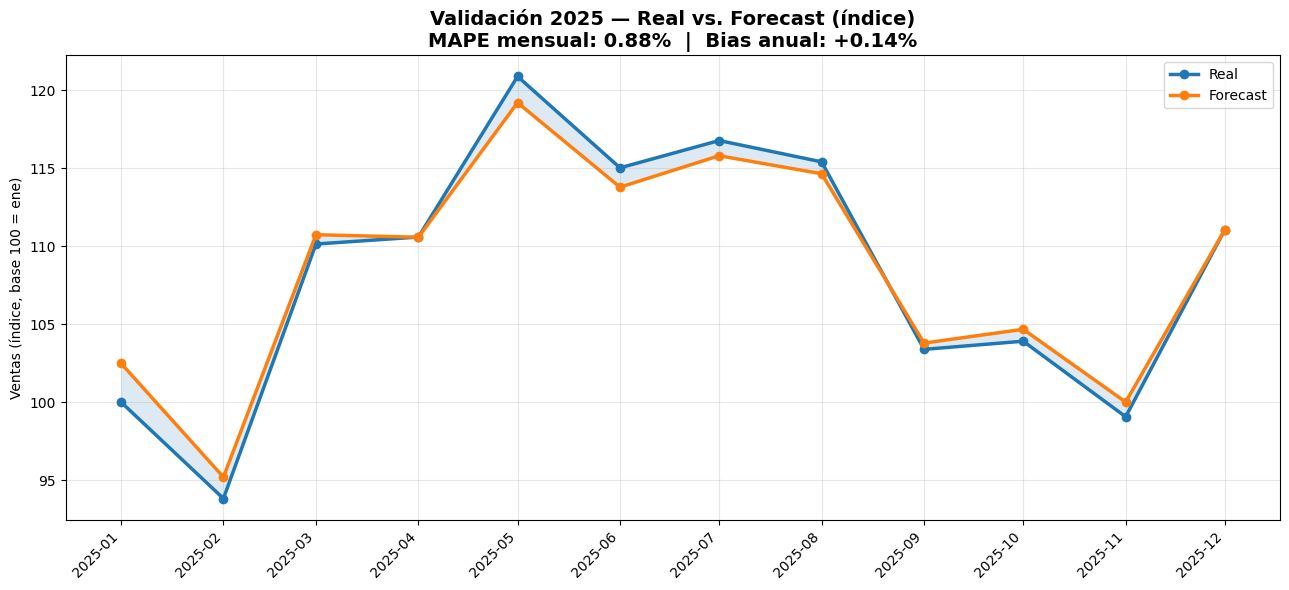

In [7]:
monthly["mdt"] = monthly["month"].dt.to_timestamp()
base100 = monthly["y"].iloc[0] / 100.0
monthly["y_idx"]    = monthly["y"]    / base100
monthly["yhat_idx"] = monthly["yhat"] / base100

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(monthly["mdt"], monthly["y_idx"],    marker="o", linewidth=2.5, label="Real")
ax.plot(monthly["mdt"], monthly["yhat_idx"], marker="o", linewidth=2.5, label="Forecast")
ax.fill_between(monthly["mdt"], monthly["y_idx"], monthly["yhat_idx"], alpha=0.15)

ax.set_title(f"Validación 2025 — Real vs. Forecast (índice)\n"
             f"MAPE mensual: {mape_monthly:.2%}  |  Bias anual: {bias_annual:+.2%}",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Ventas (índice, base 100 = ene)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(monthly["mdt"], monthly["mdt"].dt.strftime("%Y-%m"), rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Conclusión

El backtest muestra que el modelo reproduce el año de prueba con un error mensual
de un dígito bajo y un bias anual cercano a cero. En otras palabras: **el modelo
es confiable para planificación antes de ponerlo en producción.**

Este es el paso que más confianza genera en un equipo de negocio: no se trata de
"predecir el futuro", sino de demostrar, con un año real apartado, que el método
acierta de forma consistente.

**Siguiente paso del proyecto completo (no incluido aquí):** una vez validado, el
mismo motor se usa para proyectar el año siguiente y para distribuir el presupuesto
anual en metas diarias por tienda, incorporando feriados, calendario comercial,
promociones y efecto quincena.